In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Library successfully loaded")

Library successfully loaded


In [13]:
df = pd.read_csv('retail_sales_dataset.csv')

print("Dataset Shape (Rows, Columns):", df.shape)
print("\nMissing values check:\n", df.isnull().sum())
df.head()

Dataset Shape (Rows, Columns): (1000, 9)

Missing values check:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [14]:
# Extrtact month from date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# devide age in groups
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '50+']
)

df[['Date', 'Month', 'Age', 'Age Group']].head()

,Date,Month,Age,Age Group
0,2023-11-24,11,34,26-35
1,2023-02-27,2,26,26-35
2,2023-01-13,1,50,36-50
3,2023-05-21,5,37,36-50
4,2023-05-06,5,30,26-35


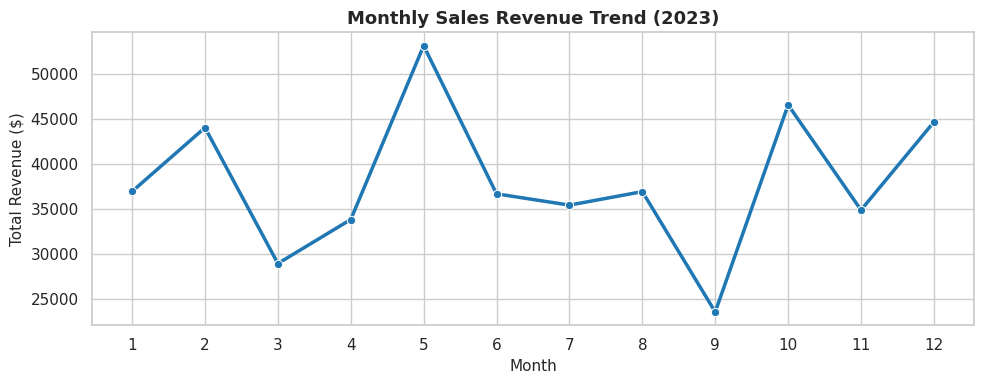

In [15]:
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_sales, x='Month', y='Total Amount', marker='o', color='#1f77b4', linewidth=2.5)
plt.title('Monthly Sales Revenue Trend (2023)', fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

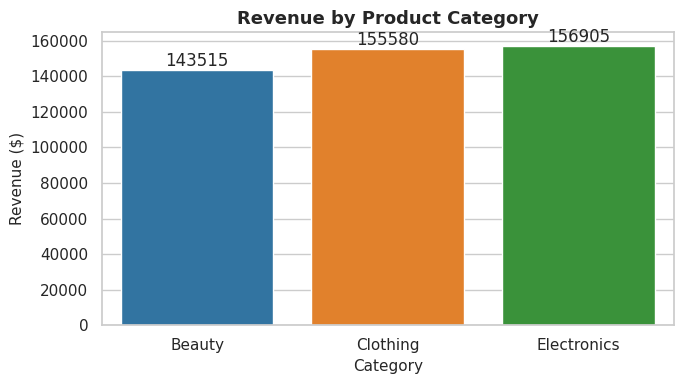

In [16]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().reset_index()

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=category_revenue, x='Product Category', y='Total Amount', hue='Product Category', palette='tab10', legend=False)
for bar in ax.containers:
    ax.bar_label(bar)

plt.title('Revenue by Product Category', fontsize=13, fontweight='bold')
plt.xlabel('Category', fontsize=11)
plt.ylabel('Revenue ($)', fontsize=11)
plt.tight_layout()
plt.show()

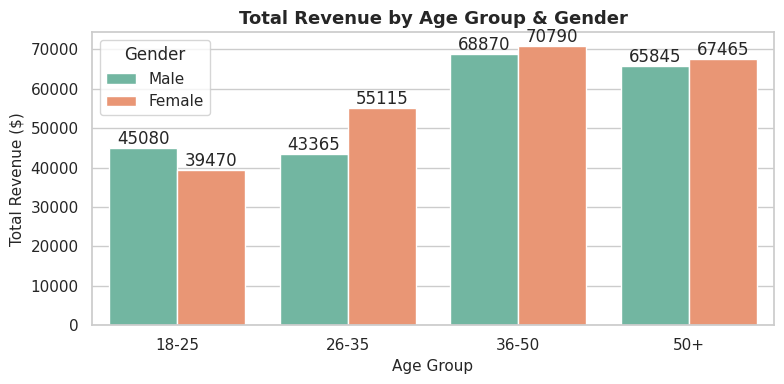


--- Summary Insights ---
Total Transactions: 1000
Total Sales: $456,000.00
Average Order Value: $456.00


In [17]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df, x='Age Group', y='Total Amount', hue='Gender', estimator=sum, errorbar=None, palette='Set2')
for bar in ax.containers:
    ax.bar_label(bar)

plt.title('Total Revenue by Age Group & Gender', fontsize=13, fontweight='bold')
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Final Business Summary
print("\n--- Summary Insights ---")
print(f"Total Transactions: {len(df)}")
print(f"Total Sales: ${df['Total Amount'].sum():,.2f}")
print(f"Average Order Value: ${df['Total Amount'].mean():.2f}")